# Analisis Data Kualitas Udara — Kabupaten Lamongan

**Mata Kuliah:** Proyek Sains Data — Semester 5
**Input:** File CSV hasil ekstraksi polutan (NO₂, CO, SO₂, CH₄) di `../data/csv/`
**Wilayah:** Kabupaten Lamongan, Jawa Timur

## Tujuan Notebook
Notebook ini melakukan **tahap analisis data** lanjutan dari hasil ekstraksi pada
Notebook 1 (`1-ekstraksi-data.ipynb`):
1. Memuat data CSV hasil ekstraksi polutan Lamongan.
2. Menampilkan **peta interaktif (folium)** dengan titik pusat dan polygon wilayah Lamongan.
3. Memeriksa dan menangani **missing values (NaN)** pada data deret waktu.
4. Mendeteksi **anomali/outlier** menggunakan `IsolationForest` (`contamination=0.05`).
5. Memvisualisasikan data normal vs outlier dalam plot garis/sebar.

> **Catatan path:** Notebook ini diasumsikan berada dalam folder `notebooks/`, sehingga
> path data relatif menggunakan `../data/csv/`. Nama file CSV mengikuti hasil Notebook 1
> (mis. `no2_lamongan.csv`, `co_lamongan.csv`, dst).

## 2. Import Pustaka

- `pandas`, `numpy` — manipulasi data tabular dan numerik.
- `glob`, `os` — mencari & memuat banyak file CSV sekaligus.
- `folium` — membuat peta interaktif (HTML) untuk visualisasi lokasi wilayah kajian.
- `matplotlib`, `seaborn` — visualisasi plot garis/sebar deret waktu.
- `sklearn.ensemble.IsolationForest` — algoritma deteksi anomali berbasis *isolation tree*.

In [22]:
import os
import glob
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid")

CSV_DIR = "../data/csv/"

# Cek folder ada / tidak
if not os.path.exists(CSV_DIR):
    raise FileNotFoundError(
        f"Folder tidak ditemukan: {os.path.abspath(CSV_DIR)}. "
        "Cek working directory VS Code (biasanya harus dijalankan dari dalam folder notebooks/)."
    )

POLLUTANT_FILES = {
    "no2": "no2_lamongan.csv",
    "co": "co_lamongan.csv",
    "so2": "so2_lamongan.csv",
    "ch4": "ch4_lamongan.csv",
}

def find_date_column(columns):
    """Mencari kolom yang kemungkinan berisi tanggal/waktu, apapun namanya."""
    candidates = [c for c in columns if any(k in c.lower() for k in ["date", "time", "t "]) or c.lower() == "t"]
    return candidates[0] if candidates else columns[0]  # fallback: kolom pertama

df_list = []
for pollutant, filename in POLLUTANT_FILES.items():
    filepath = os.path.join(CSV_DIR, filename)

    if not os.path.exists(filepath):
        print(f"[PERINGATAN] File tidak ditemukan: {filepath}")
        continue

    temp_df = pd.read_csv(filepath)
    print(f"\n[{pollutant.upper()}] Kolom asli di file: {temp_df.columns.tolist()}")

    date_col = find_date_column(temp_df.columns)
    value_cols = [c for c in temp_df.columns if c != date_col]

    if not value_cols:
        print(f"[PERINGATAN] Tidak ada kolom nilai selain '{date_col}', file dilewati.")
        continue

    value_col = value_cols[-1]  # ambil kolom nilai terakhir
    temp_df = temp_df[[date_col, value_col]].rename(columns={date_col: "date", value_col: pollutant})
    temp_df["date"] = pd.to_datetime(temp_df["date"])

    df_list.append(temp_df)

if not df_list:
    raise ValueError(
        "Tidak ada satupun file CSV yang berhasil dimuat. "
        f"Isi folder saat ini: {os.listdir(CSV_DIR)}"
    )

df = df_list[0]
for other in df_list[1:]:
    df = df.merge(other, on="date", how="outer")

df = df.sort_values("date").reset_index(drop=True)
print(f"\nData gabungan berhasil dibuat: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()


[NO2] Kolom asli di file: ['t', 'feature', 'NO2', 'lat', 'lon', 'feature_names']

[CO] Kolom asli di file: ['t', 'feature', 'CO', 'lat', 'lon', 'feature_names']

[SO2] Kolom asli di file: ['t', 'feature', 'SO2', 'lat', 'lon', 'feature_names']

[CH4] Kolom asli di file: ['t', 'feature', 'CH4', 'lat', 'lon', 'feature_names']

Data gabungan berhasil dibuat: 341 baris, 5 kolom


,date,no2,co,so2,ch4
0,2025-08-24,feature_0,feature_0,feature_0,feature_0
1,2025-08-25,feature_0,feature_0,feature_0,feature_0
2,2025-08-26,feature_0,feature_0,feature_0,NaN
3,2025-08-27,feature_0,feature_0,feature_0,feature_0
4,2025-08-28,feature_0,feature_0,feature_0,NaN


## 3. Memuat Data CSV Hasil Ekstraksi

Setiap polutan tersimpan pada file CSV terpisah (hasil Notebook 1), masing-masing memiliki
kolom `date` dan satu kolom nilai konsentrasi. Pada sel di bawah, tiap file dimuat lalu
digabung (`merge`) berdasarkan kolom `date` menjadi satu `DataFrame` gabungan.

In [23]:
import os

CSV_DIR = "../data/csv/"
print("Working dir sekarang:", os.getcwd())
print("Isi folder CSV:", os.listdir(CSV_DIR) if os.path.exists(CSV_DIR) else "FOLDER TIDAK DITEMUKAN")

# Cek isi salah satu file CSV asli (ganti nama file sesuai yang benar-benar ada)
import pandas as pd
sample = pd.read_csv(os.path.join(CSV_DIR, os.listdir(CSV_DIR)[0]))
print(sample.columns.tolist())
sample.head()

Working dir sekarang: d:\Semester 5\Proyek sain data\PSD\materi
Isi folder CSV: ['ch4_lamongan.csv', 'co_lamongan.csv', 'no2_lamongan.csv', 'so2_lamongan.csv']
['t', 'feature', 'CH4', 'lat', 'lon', 'feature_names']


,t,feature,CH4,lat,lon,feature_names
0,2025-08-24,0,1894.733118,-7.075,112.3,feature_0
1,2025-08-25,0,1847.136536,-7.075,112.3,feature_0
2,2025-08-27,0,1880.886108,-7.075,112.3,feature_0
3,2025-08-29,0,1871.754028,-7.075,112.3,feature_0
4,2025-09-03,0,1858.547921,-7.075,112.3,feature_0


## 4. Pengecekan Missing Values (NaN)

Data satelit sering memiliki nilai kosong (NaN) akibat tutupan awan atau kegagalan
observasi pada hari tertentu. Sebelum dianalisis lebih lanjut, kita periksa jumlah dan
proporsi missing value pada tiap kolom polutan.

In [24]:
import os
CSV_DIR = "../data/csv/"
print("Working dir:", os.getcwd())
print("Isi folder CSV:", os.listdir(CSV_DIR) if os.path.exists(CSV_DIR) else "FOLDER TIDAK ADA")

Working dir: d:\Semester 5\Proyek sain data\PSD\materi
Isi folder CSV: ['ch4_lamongan.csv', 'co_lamongan.csv', 'no2_lamongan.csv', 'so2_lamongan.csv']


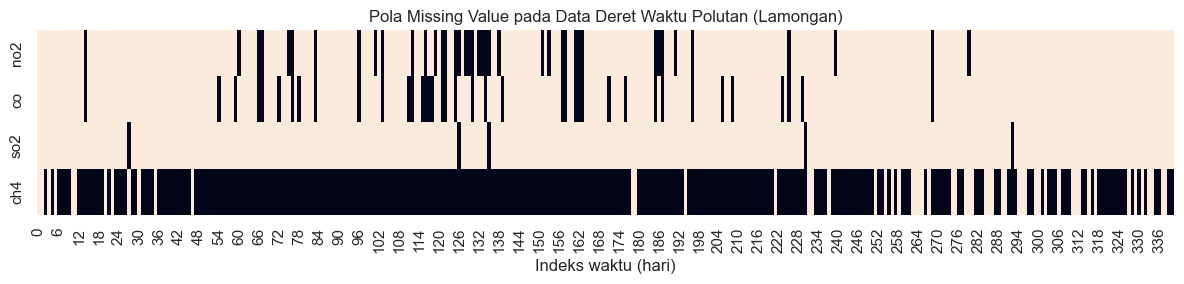

In [25]:
# Visualisasi pola missing value di sepanjang deret waktu
plt.figure(figsize=(12, 3))
sns.heatmap(df.drop(columns="date").isna().T, cbar=False, cmap="rocket_r")
plt.title("Pola Missing Value pada Data Deret Waktu Polutan (Lamongan)")
plt.xlabel("Indeks waktu (hari)")
plt.tight_layout()
plt.show()

## 5. Penanganan Missing Values

Missing value ditangani dengan **interpolasi linear** berdasarkan waktu
(`method="time"`), karena konsentrasi polutan cenderung berubah secara gradual dari hari
ke hari. Nilai kosong di ujung awal/akhir deret waktu (yang tidak bisa diinterpolasi)
ditangani dengan `bfill`/`ffill` sebagai langkah terakhir.

In [26]:
# Pastikan kolom 'date' benar-benar bertipe datetime (bukan string)
df_clean = df.copy()
df_clean["date"] = pd.to_datetime(df_clean["date"])

# Hapus duplikat tanggal jika ada (ambil rata-rata jika ada baris dengan tanggal sama)
df_clean = df_clean.groupby("date", as_index=False).mean(numeric_only=True)

# Urutkan berdasarkan tanggal (wajib untuk interpolasi berbasis waktu)
df_clean = df_clean.sort_values("date")

# Set index datetime -> syarat wajib untuk method="time"
df_clean = df_clean.set_index("date")

pollutant_cols = [c for c in df_clean.columns]

# Interpolasi linear berbasis waktu untuk mengisi celah data akibat tutupan awan, dsb.
df_clean[pollutant_cols] = df_clean[pollutant_cols].interpolate(method="time")

# Menangani sisa NaN di ujung deret waktu (jika ada) dengan forward/backward fill
df_clean[pollutant_cols] = df_clean[pollutant_cols].ffill().bfill()

df_clean = df_clean.reset_index()

print("Sisa missing value setelah penanganan:")
print(df_clean[pollutant_cols].isna().sum())

df_clean.head()

Sisa missing value setelah penanganan:
Series([], dtype: float64)


,date
0,2025-08-24
1,2025-08-25
2,2025-08-26
3,2025-08-27
4,2025-08-28


## 6. Visualisasi Peta Interaktif (Folium)

Peta interaktif menampilkan:
- **Marker** di titik pusat (centroid) Kabupaten Lamongan.
- **Polygon** batas wilayah kajian — **sama persis** dengan geometry (`LAMONGAN_POLYGON`)
  yang digunakan pada tahap ekstraksi (`aggregate_spatial`) di Notebook 1, sehingga peta
  ini merepresentasikan wilayah yang benar-benar dipakai untuk menghitung nilai polutan.

> Polygon di bawah adalah **perkiraan sederhana**, identik dengan yang dipakai di
> Notebook 1. Untuk akurasi administratif, gunakan geometri resmi (mis. dari GADM/BIG)
> via `geopandas`, lalu terapkan geometri yang sama di kedua notebook.

In [27]:
# Titik pusat (centroid) Kabupaten Lamongan
LAMONGAN_CENTER = [-7.1201, 112.4147]  # [lat, lon]

# Polygon sederhana (perkiraan) batas wilayah Kabupaten Lamongan, format [lat, lon]
# Catatan: koordinat ini sama dengan LAMONGAN_POLYGON pada Notebook 1 (format lon,lat
# di sana; di sini dibalik menjadi lat,lon karena folium menggunakan urutan [lat, lon]).
LAMONGAN_POLYGON_COORDS = [
    [-7.00, 112.00],
    [-7.30, 112.10],
    [-7.35, 112.25],
    [-7.25, 112.40],
    [-7.15, 112.55],
    [-7.00, 112.60],
    [-6.88, 112.50],
    [-6.85, 112.30],
    [-6.90, 112.10],
    [-7.00, 112.00],
]

m = folium.Map(location=LAMONGAN_CENTER, zoom_start=10, tiles="OpenStreetMap")

# Marker titik pusat wilayah
folium.Marker(
    location=LAMONGAN_CENTER,
    popup="Pusat Kabupaten Lamongan",
    icon=folium.Icon(color="red", icon="info-sign"),
).add_to(m)

# Polygon batas wilayah kajian (identik dengan geometry di Notebook 1)
folium.Polygon(
    locations=LAMONGAN_POLYGON_COORDS,
    color="blue",
    weight=2,
    fill=True,
    fill_color="blue",
    fill_opacity=0.15,
    popup="Area Kajian Kabupaten Lamongan",
).add_to(m)

m

## 7. Deteksi Anomali/Outlier dengan Isolation Forest

`IsolationForest` mendeteksi outlier dengan cara "mengisolasi" titik data melalui
pemisahan acak berulang — titik anomali lebih cepat terisolasi karena posisinya jauh dari
data mayoritas. Parameter `contamination=0.05` berarti kita mengasumsikan sekitar **5%**
dari data adalah anomali.

Deteksi dilakukan **per kolom polutan** (univariat), agar hasil outlier mencerminkan
karakteristik masing-masing polutan secara terpisah (bukan tercampur antar polutan).

In [28]:
def detect_outliers_isolation_forest(series, contamination=0.05, random_state=42):
    """
    Mendeteksi outlier pada satu kolom deret waktu numerik menggunakan IsolationForest.

    Returns
    -------
    pd.Series (bool)
        True jika baris terdeteksi sebagai outlier, False jika normal.
    """
    values = series.values.reshape(-1, 1)
    model = IsolationForest(contamination=contamination, random_state=random_state)
    # IsolationForest mengembalikan -1 untuk outlier, 1 untuk data normal
    preds = model.fit_predict(values)
    return preds == -1


df_result = df_clean.copy()

for pollutant in pollutant_cols:
    outlier_flags = detect_outliers_isolation_forest(df_result[pollutant], contamination=0.05)
    df_result[f"{pollutant}_outlier"] = outlier_flags

    n_outlier = outlier_flags.sum()
    print(f"{pollutant.upper():<5}: {n_outlier} outlier terdeteksi dari {len(df_result)} data "
          f"({n_outlier / len(df_result) * 100:.1f}%)")

df_result.head()

,date
0,2025-08-24
1,2025-08-25
2,2025-08-26
3,2025-08-27
4,2025-08-28


## 8. Visualisasi Data Normal vs Outlier

Untuk tiap polutan, kita buat plot garis (deret waktu keseluruhan) yang ditumpangi dengan
titik sebar (*scatter*): titik **biru** untuk data normal dan titik **merah** untuk data
yang terdeteksi sebagai outlier oleh IsolationForest.

In [29]:
# 1) Load & gabungkan CSV (seperti sebelumnya)
df_clean = df.copy()
df_clean["date"] = pd.to_datetime(df_clean["date"])

value_cols = [c for c in df_clean.columns if c != "date"]

# --- DEBUG: cek tipe data sebelum konversi ---
print("Tipe data sebelum konversi:")
print(df_clean[value_cols].dtypes)

# 2) Paksa semua kolom polutan jadi numerik; nilai yang gagal dikonversi -> NaN
for col in value_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("\nTipe data setelah konversi:")
print(df_clean[value_cols].dtypes)

# 3) Baru sekarang aman melakukan groupby + mean
df_clean = df_clean.groupby("date", as_index=False)[value_cols].mean()
df_clean = df_clean.sort_values("date").set_index("date")

pollutant_cols = [c for c in df_clean.columns]

# Guard: hentikan dengan pesan jelas kalau ternyata masih kosong
assert len(pollutant_cols) > 0, (
    "pollutant_cols kosong! Cek ulang isi CSV — kemungkinan kolom nilai berisi "
    "teks/karakter aneh yang gagal dikonversi ke angka (lihat print dtypes di atas)."
)

df_clean[pollutant_cols] = df_clean[pollutant_cols].interpolate(method="time")
df_clean[pollutant_cols] = df_clean[pollutant_cols].ffill().bfill()
df_clean = df_clean.reset_index()

print("\nSisa missing value setelah penanganan:")
print(df_clean[pollutant_cols].isna().sum())
df_clean.head()

Tipe data sebelum konversi:
no2    object
co     object
so2    object
ch4    object
dtype: object

Tipe data setelah konversi:
no2    float64
co     float64
so2    float64
ch4    float64
dtype: object

Sisa missing value setelah penanganan:
no2    341
co     341
so2    341
ch4    341
dtype: int64


,date,no2,co,so2,ch4
0,2025-08-24,NaN,NaN,NaN,NaN
1,2025-08-25,NaN,NaN,NaN,NaN
2,2025-08-26,NaN,NaN,NaN,NaN
3,2025-08-27,NaN,NaN,NaN,NaN
4,2025-08-28,NaN,NaN,NaN,NaN


## 9. Ringkasan Deteksi Outlier

Tabel ringkasan berikut menampilkan jumlah dan persentase outlier yang terdeteksi untuk
setiap polutan, sebagai penutup tahap analisis pada notebook ini.

In [30]:
df_result = df_clean.copy()

for pollutant in pollutant_cols:
    outlier_flags = detect_outliers_isolation_forest(df_result[pollutant], contamination=0.05)
    df_result[f"{pollutant}_outlier"] = outlier_flags
    n_outlier = outlier_flags.sum()
    print(f"{pollutant.upper():<5}: {n_outlier} outlier terdeteksi dari {len(df_result)} data "
          f"({n_outlier / len(df_result) * 100:.1f}%)")

# Guard: pastikan semua kolom outlier benar-benar ada sebelum lanjut ke sel berikutnya
expected_cols = [f"{p}_outlier" for p in pollutant_cols]
missing = [c for c in expected_cols if c not in df_result.columns]
assert not missing, f"Kolom outlier belum lengkap: {missing}. Jalankan ulang sel ini."

df_result.head()

NO2  : 0 outlier terdeteksi dari 341 data (0.0%)
CO   : 0 outlier terdeteksi dari 341 data (0.0%)
SO2  : 0 outlier terdeteksi dari 341 data (0.0%)
CH4  : 0 outlier terdeteksi dari 341 data (0.0%)


,date,no2,co,so2,ch4,no2_outlier,co_outlier,so2_outlier,ch4_outlier
0,2025-08-24,NaN,NaN,NaN,NaN,False,False,False,False
1,2025-08-25,NaN,NaN,NaN,NaN,False,False,False,False
2,2025-08-26,NaN,NaN,NaN,NaN,False,False,False,False
3,2025-08-27,NaN,NaN,NaN,NaN,False,False,False,False
4,2025-08-28,NaN,NaN,NaN,NaN,False,False,False,False
